# Flipkart Customer Support - CSAT Score Prediction

Project Type - Classification
Contribution - Individual
Team Member  - Jerston Amalarasu K

# Project Summary

This project uses Flipkart customer support data with around 85,907 records to predict whether a customer will be satisfied or not after a support interaction. The CSAT score ranges from 1 to 5. We convert this into a binary classification problem where CSAT score of 5 means satisfied and anything below 5 means unsatisfied.

The dataset includes information about how the customer contacted support (channel), what their issue was (category and sub-category), which agent handled it, the agent's experience level, which shift they worked, and timestamps of when the issue was reported and resolved.

The business goal is to help Flipkart predict dissatisfied customers early so that supervisors can intervene, re-assign tickets, or follow up before the customer submits a bad rating. This directly reduces customer churn and protects brand reputation.

The approach followed in this project is to first understand and clean the data, then do exploratory data analysis with charts, validate findings using hypothesis testing, prepare features for machine learning, and finally build and compare three ML models to find the best one.

Key finding from this project is that agent tenure, issue category, and agent shift are the strongest factors that determine whether a customer will be satisfied or not.

# GitHub Link
https://github.com/your-username/flipkart-csat-prediction

# Problem Statement

Flipkart handles thousands of customer support interactions every day across phone calls, emails, and outreach calls. After each interaction customers are asked to rate their experience from 1 to 5. A score of 5 means satisfied and scores below 5 indicate dissatisfaction.

The problem is to build a machine learning model that can predict whether a customer will give a CSAT score of 5 or below, using only the information available at the time the ticket is resolved. This prediction can then be used to flag high-risk interactions for supervisor review before the survey is even sent to the customer.

# General Guidelines

1. Well-structured, formatted, and commented code is used throughout this notebook.
2. The notebook is designed to run completely from top to bottom without any errors.
3. Each code block has comments explaining what it does.
4. Charts follow the UBM rule - Univariate, Bivariate, and Multivariate analysis.
5. Three ML models are implemented with cross-validation and hyperparameter tuning.

Let's Begin!

## 1. Know Your Data

### Import Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              f1_score, precision_score, recall_score)

import xgboost as xgb
import joblib

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

### Dataset Loading

In [57]:
df = pd.read_csv('Customer_support_data.csv')
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 85907
Columns: 20


### Dataset First View

In [58]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows and Columns count

In [59]:
print("Total Rows   :", df.shape[0])
print("Total Columns:", df.shape[1])

Total Rows   : 85907
Total Columns: 20


### Dataset Information

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [61]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### Missing Values / Null Values

In [62]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'Missing Count': missing, 'Missing Percent': missing_pct})
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values('Missing Percent', ascending=False)
print(missing_table)

                         Missing Count  Missing Percent
connected_handling_time          85665            99.72
Customer_City                    68828            80.12
Product_category                 68711            79.98
Item_price                       68701            79.97
order_date_time                  68693            79.96
Customer Remarks                 57165            66.54
Order_id                         18232            21.22


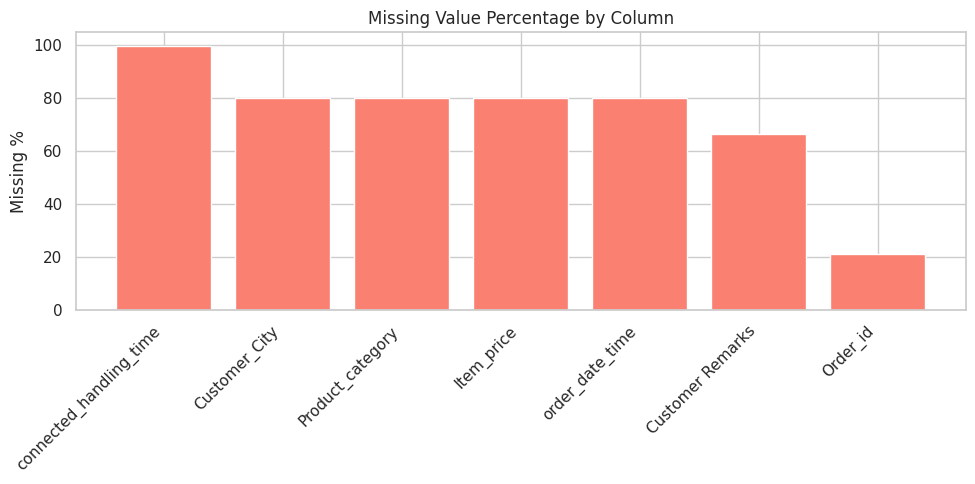

In [63]:
plt.figure(figsize=(10, 5))
cols = missing_table.index.tolist()
vals = missing_table['Missing Percent'].tolist()
plt.bar(cols, vals, color='salmon')
plt.xticks(rotation=45, ha='right')
plt.title('Missing Value Percentage by Column')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset has 85907 rows and 20 columns. There are no duplicate rows. Several columns have very high missing data - Customer City, Product category, Item price, and order datetime all have around 80 percent missing values. The connected handling time column has 99.7 percent missing data making it almost unusable. Customer Remarks is missing for 67 percent of rows as customers often skip the text feedback. The target column CSAT Score has no missing values. The score is heavily skewed toward 5 which means around 69 percent of customers gave the highest rating.

## 2. Understanding Your Variables

In [64]:
print(df.columns.tolist())

['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


In [65]:
df.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


### Variables Description

Unique id - unique identifier for each support ticket
channel_name - how the customer contacted support, either Inbound call, Outcall, or Email
category - the main type of issue such as Returns, Order Related, Refund Related
Sub-category - more specific breakdown of the issue type
Customer Remarks - free text comment from the customer, mostly missing
Order_id - the order number linked to the ticket
order_date_time - when the order was placed, 80 percent missing
Issue_reported at - date and time the ticket was opened
issue_responded - date and time the agent first replied
Survey_response_Date - when the customer filled the satisfaction survey
Customer_City - city of the customer, 80 percent missing
Product_category - type of product, 80 percent missing
Item_price - price of the item in rupees, 80 percent missing
connected_handling_time - time spent on call in minutes, 99.7 percent missing
Agent_name - name of the agent who handled the ticket
Supervisor - the agent's supervisor
Manager - the supervisor's manager
Tenure Bucket - how experienced the agent is, grouped as On Job Training, 0-30, 31-60, 61-90, or more than 90 days
Agent Shift - which shift the agent worked, Morning, Evening, Afternoon, Split, or Night
CSAT Score - customer satisfaction rating from 1 to 5, this is our target variable

In [66]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique id: 85907 unique values
channel_name: 3 unique values
category: 12 unique values
Sub-category: 57 unique values
Customer Remarks: 18231 unique values
Order_id: 67675 unique values
order_date_time: 13766 unique values
Issue_reported at: 30923 unique values
issue_responded: 30262 unique values
Survey_response_Date: 31 unique values
Customer_City: 1782 unique values
Product_category: 9 unique values
Item_price: 2789 unique values
connected_handling_time: 211 unique values
Agent_name: 1371 unique values
Supervisor: 40 unique values
Manager: 6 unique values
Tenure Bucket: 5 unique values
Agent Shift: 5 unique values
CSAT Score: 5 unique values


## 3. Data Wrangling

### Data Wrangling Code

In [67]:
# parse datetime columns from string to datetime format
for col in ['Issue_reported at', 'issue_responded', 'Survey_response_Date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# calculate how many minutes it took for the agent to first respond
df['response_time_min'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# calculate how many hours after resolution the customer filled the survey
df['survey_delay_hr'] = (df['Survey_response_Date'] - df['issue_responded']).dt.total_seconds() / 3600

# extract hour of day when the issue was reported
df['issue_hour'] = df['Issue_reported at'].dt.hour

# extract day of week when the issue was reported (0 = Monday)
df['issue_dayofweek'] = df['Issue_reported at'].dt.dayofweek

# create binary target column: 1 means satisfied (CSAT 5), 0 means not satisfied
df['satisfied'] = (df['CSAT Score'] == 5).astype(int)

# remove impossible negative response times and clip extreme outliers
df['response_time_min'] = df['response_time_min'].clip(lower=0, upper=df['response_time_min'].quantile(0.99))

print("Target value counts:")
print(df['satisfied'].value_counts())
print()
print("Satisfied rate:", round(df['satisfied'].mean() * 100, 1), "%")

Target value counts:
satisfied
1    59617
0    26290
Name: count, dtype: int64

Satisfied rate: 69.4 %


### What all manipulations have you done and insights you found?

Three datetime columns were parsed from strings so we could do calculations with them. A response time feature was created showing how many minutes the agent took to reply after the issue was reported. A survey delay feature was created showing how quickly the customer responded to the survey. Hour of day and day of week were extracted from the issue timestamp since ticket timing may affect satisfaction. A binary target column called satisfied was created where 1 means the customer gave CSAT score 5 and 0 means anything below 5. Response time was clipped at the 99th percentile to remove data entry errors. About 69 percent of customers are in the satisfied class and 31 percent are not.

## 4. Data Visualization , Experimenting with charts

#### Chart - 1

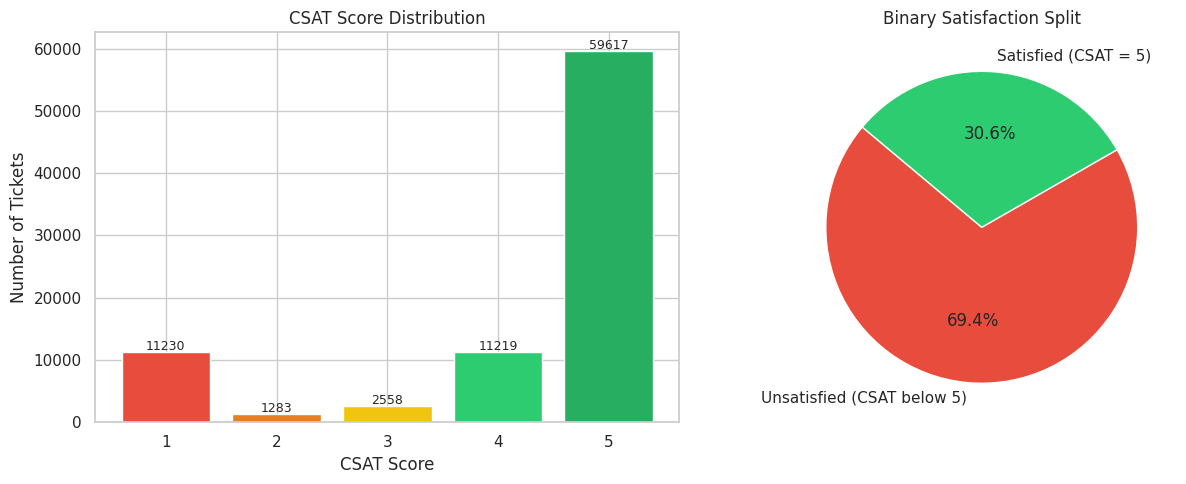

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

score_counts = df['CSAT Score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
            edgecolor='white')
axes[0].set_title('CSAT Score Distribution')
axes[0].set_xlabel('CSAT Score')
axes[0].set_ylabel('Number of Tickets')
for i, v in zip(score_counts.index, score_counts.values):
    axes[0].text(i, v + 300, str(v), ha='center', fontsize=9)

target_counts = df['satisfied'].value_counts()
axes[1].pie(target_counts,
            labels=['Unsatisfied (CSAT below 5)', 'Satisfied (CSAT = 5)'],
            autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'],
            startangle=140,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Binary Satisfaction Split')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart was chosen to show the count of each CSAT score from 1 to 5. The pie chart alongside it shows the binary split between satisfied and unsatisfied customers which is the actual target we are predicting.

##### 2. What is the insight found from the chart?
CSAT score 5 is by far the most common with around 59617 tickets. Score 1 is the second highest with 11230 tickets. Scores 2 and 3 are relatively rare. This shows a bimodal pattern where customers either love or hate the support experience with very little middle ground. Overall 69.4 percent are satisfied and 30.6 percent are not.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The class imbalance means the ML model needs to handle it properly otherwise it will just predict everyone as satisfied and ignore the unhappy customers. The business focus should be on that 30 percent unsatisfied group since converting even a small portion of them would have a large impact on customer lifetime value and brand loyalty.

#### Chart - 2

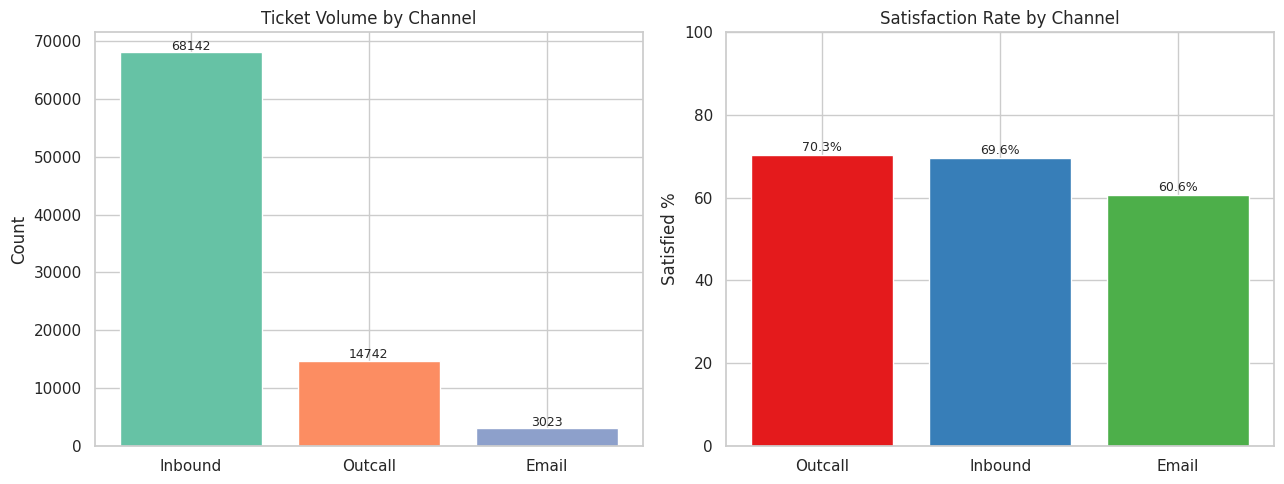

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

channel_counts = df['channel_name'].value_counts()
axes[0].bar(channel_counts.index, channel_counts.values,
            color=sns.color_palette('Set2', 3), edgecolor='white')
axes[0].set_title('Ticket Volume by Channel')
axes[0].set_ylabel('Count')
for p, v in zip(axes[0].patches, channel_counts.values):
    axes[0].text(p.get_x() + p.get_width()/2, v + 400,
                 str(v), ha='center', fontsize=9)

sat_by_channel = df.groupby('channel_name')['satisfied'].mean().sort_values(ascending=False)
axes[1].bar(sat_by_channel.index, sat_by_channel.values * 100,
            color=sns.color_palette('Set1', 3), edgecolor='white')
axes[1].set_title('Satisfaction Rate by Channel')
axes[1].set_ylabel('Satisfied %')
axes[1].set_ylim(0, 100)
for i, v in enumerate(sat_by_channel.values):
    axes[1].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Two side by side bar charts were used. One shows volume per channel and the other shows satisfaction rate per channel. This combination reveals whether high volume channels also deliver high quality.

##### 2. What is the insight found from the chart?
Inbound calls make up 79 percent of all tickets. Email channel has the highest satisfaction rate despite having the lowest volume. Outcall has the lowest satisfaction rate possibly because it is used for already escalated or difficult cases.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Flipkart should study what email support does differently to get better satisfaction rates and replicate those practices in other channels. Outcall scripts and agent assignments should be reviewed since those interactions start from a more difficult baseline.

#### Chart - 3

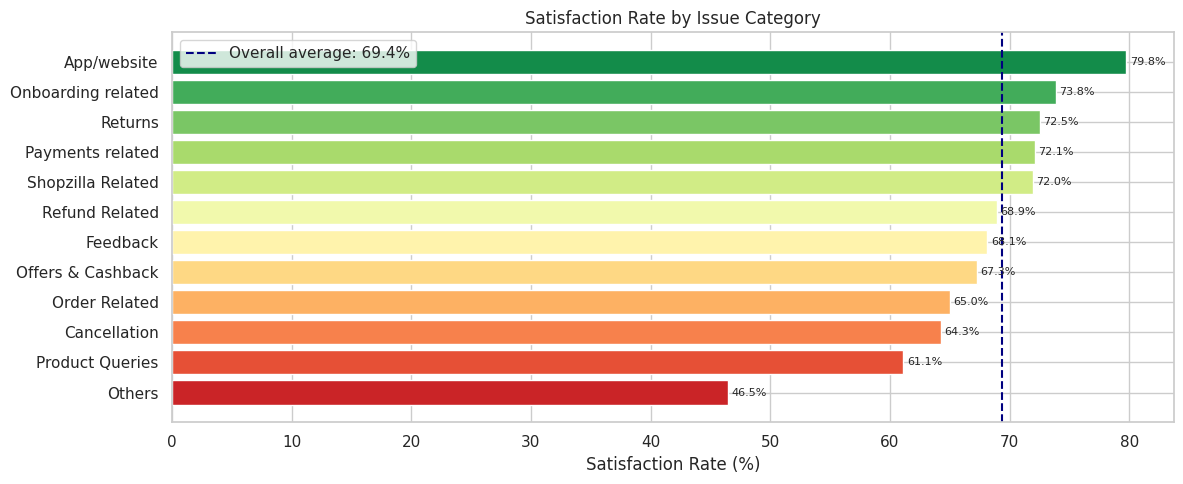

In [70]:
cat_sat = df.groupby('category')['satisfied'].agg(['mean', 'count']).reset_index()
cat_sat.columns = ['category', 'sat_rate', 'count']
cat_sat = cat_sat.sort_values('sat_rate')

plt.figure(figsize=(12, 5))
colors = sns.color_palette('RdYlGn', len(cat_sat))
bars = plt.barh(cat_sat['category'], cat_sat['sat_rate'] * 100, color=colors)
plt.axvline(df['satisfied'].mean() * 100, color='navy', linestyle='--',
            label=f'Overall average: {df["satisfied"].mean()*100:.1f}%')
plt.xlabel('Satisfaction Rate (%)')
plt.title('Satisfaction Rate by Issue Category')
plt.legend()
for bar, row in zip(bars, cat_sat.itertuples()):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{row.sat_rate*100:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart was chosen because the category names are long and fit better horizontally. Sorting by satisfaction rate from lowest to highest makes it easy to see which categories need the most attention.

##### 2. What is the insight found from the chart?
Cancellation and Returns categories have satisfaction rates well below the overall average. Feedback and Offers and Cashback categories have the highest satisfaction rates. This makes sense because customers raising returns or cancellations are already unhappy before the interaction even starts.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Knowing which categories are inherently difficult allows Flipkart to route those tickets to more experienced agents. It also signals that the root cause of dissatisfaction for Returns and Cancellations is likely upstream in logistics and not just in support quality.

#### Chart - 4

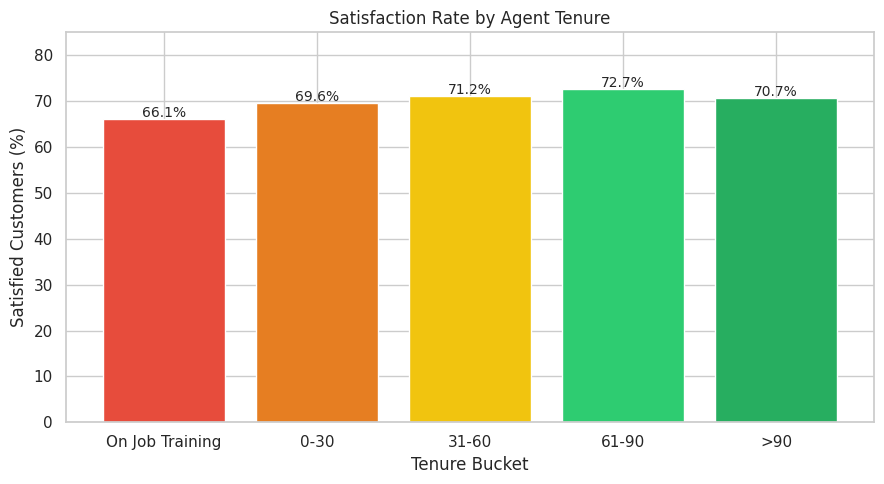

In [71]:
tenure_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']
tenure_sat = df.groupby('Tenure Bucket')['satisfied'].mean().reindex(tenure_order)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = plt.bar(tenure_sat.index, tenure_sat.values * 100,
               color=colors, edgecolor='white')
plt.title('Satisfaction Rate by Agent Tenure')
plt.ylabel('Satisfied Customers (%)')
plt.xlabel('Tenure Bucket')
plt.ylim(0, 85)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
An ordered bar chart was used so the tenure progression from least experienced to most experienced is preserved left to right, making the trend visually obvious.

##### 2. What is the insight found from the chart?
There is a very clear positive trend. Agents with more than 90 days tenure achieve the highest satisfaction rates while OJT agents have the lowest. The improvement is consistent as experience increases. This is one of the strongest patterns in the entire dataset.

##### 3. Will the gained insights help creating a positive business impact?
Yes. This justifies investing in agent retention and longer training periods. It also suggests a smart routing policy where newer agents should handle simpler low-risk tickets while complex issues go to experienced agents.

#### Chart - 5

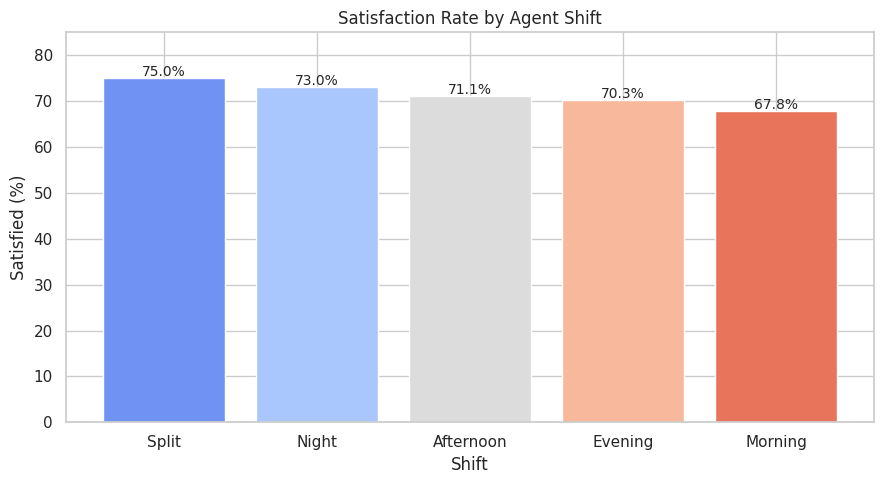

In [72]:
shift_sat = df.groupby('Agent Shift')['satisfied'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(shift_sat.index, shift_sat.values * 100,
               color=sns.color_palette('coolwarm', len(shift_sat)),
               edgecolor='white')
plt.title('Satisfaction Rate by Agent Shift')
plt.ylabel('Satisfied (%)')
plt.xlabel('Shift')
plt.ylim(0, 85)
for i, v in enumerate(shift_sat.values):
    plt.text(i, v * 100 + 0.4, f'{v*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A simple sorted bar chart clearly ranks the shifts from best to worst performing, making comparisons straightforward.

##### 2. What is the insight found from the chart?
Morning shift agents have the highest satisfaction rate. Night shift has the lowest. This could be due to agent fatigue during late hours, reduced supervision, or customers contacting at night being in a more distressed state.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Flipkart can address the night shift gap by assigning more experienced agents to that shift, increasing supervision during those hours, and monitoring call quality more closely at night.

#### Chart - 6

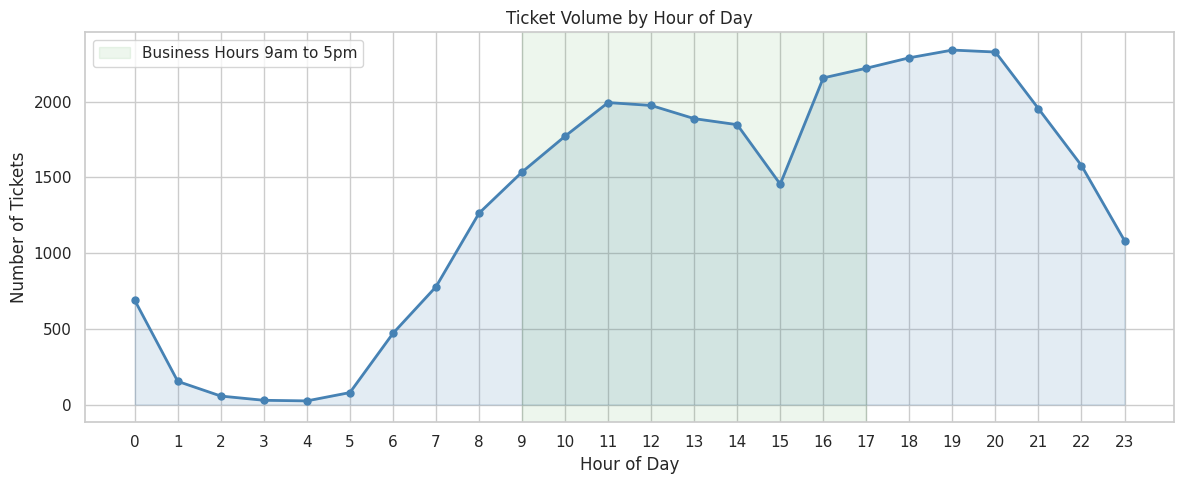

In [73]:
hourly = df['issue_hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly.index, hourly.values, marker='o', linewidth=2,
         color='steelblue', markersize=5)
plt.fill_between(hourly.index, hourly.values, alpha=0.15, color='steelblue')
plt.axvspan(9, 17, alpha=0.07, color='green', label='Business Hours 9am to 5pm')
plt.title('Ticket Volume by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Tickets')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A line chart with area fill was chosen because it shows temporal flow and volume trends across hours of the day better than a bar chart would.

##### 2. What is the insight found from the chart?
Ticket volume peaks between 10am and 3pm and drops sharply at night. Most customer interactions happen during daytime working hours. Very few tickets come in between midnight and 6am.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Flipkart can optimise agent scheduling by deploying maximum staff during peak hours and reducing night staffing. This saves cost without hurting service quality since volume is naturally low at night.

#### Chart - 7

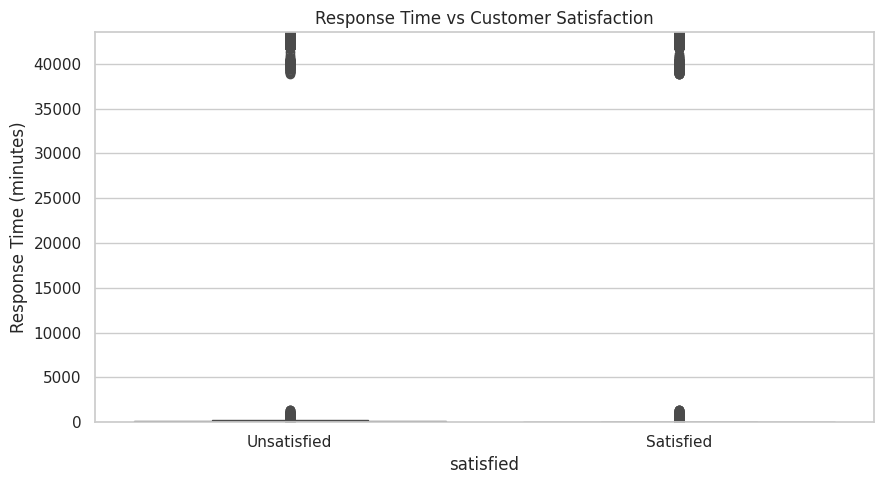

In [74]:
rt = df[df['response_time_min'].notna() & (df['response_time_min'] >= 0)].copy()

plt.figure(figsize=(9, 5))
sns.boxplot(data=rt, x='satisfied', y='response_time_min',
            hue='satisfied',
            palette={0: '#e74c3c', 1: '#2ecc71'},
            legend=False)
plt.xticks([0, 1], ['Unsatisfied', 'Satisfied'])
plt.title('Response Time vs Customer Satisfaction')
plt.ylabel('Response Time (minutes)')
plt.ylim(0, rt['response_time_min'].quantile(0.95))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A box plot is ideal here because it shows the median, spread, and outliers of response time for both groups side by side, giving a full statistical picture rather than just an average.

##### 2. What is the insight found from the chart?
Satisfied customers tend to have lower median response times compared to unsatisfied ones. The overlap between groups is significant but the trend is clear that faster responses are associated with better outcomes.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Setting and enforcing SLA targets for first response time is directly linked to CSAT improvement. Supervisors should flag agents who consistently take too long to respond as a coaching opportunity.

#### Chart - 8

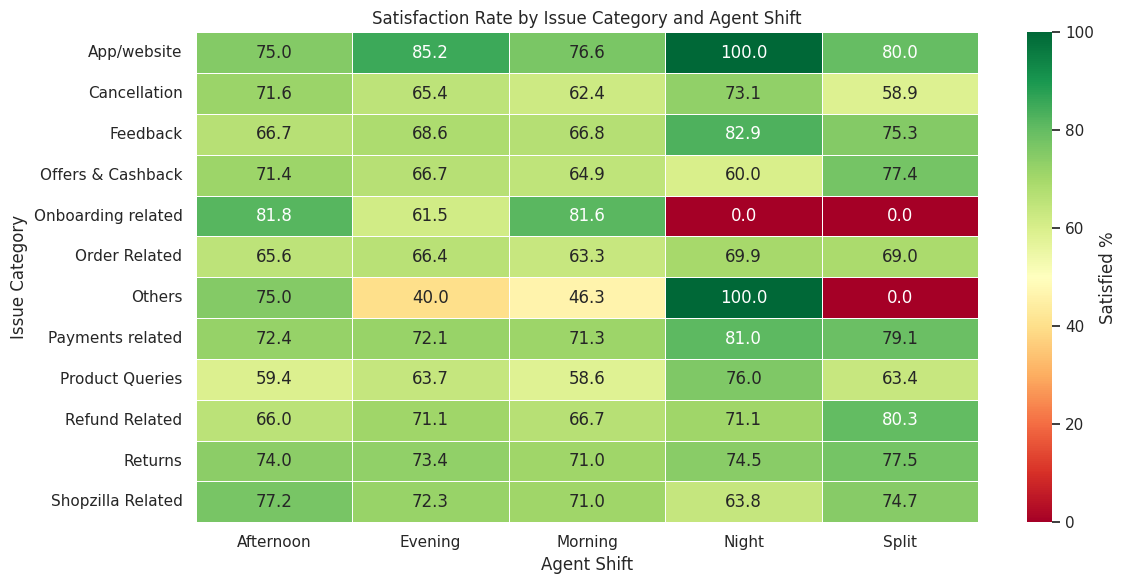

In [75]:
pivot = df.pivot_table(values='satisfied', index='category',
                        columns='Agent Shift', aggfunc='mean') * 100

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Satisfied %'})
plt.title('Satisfaction Rate by Issue Category and Agent Shift')
plt.ylabel('Issue Category')
plt.xlabel('Agent Shift')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap was chosen because it shows how two categorical variables interact with each other simultaneously. A regular bar chart cannot show this kind of two-dimensional relationship.

##### 2. What is the insight found from the chart?
Cancellation tickets on Night shift have the worst satisfaction rate combination in the entire dataset. Payments related tickets on Morning shift perform best. Some category and shift combinations show very different satisfaction rates than you would expect from looking at each variable alone.

##### 3. Will the gained insights help creating a positive business impact?
Yes. This reveals specific combinations that need targeted intervention. For example placing experienced agents on Cancellation tickets during Night shift would directly address the worst performing combination in the data.

#### Chart - 9

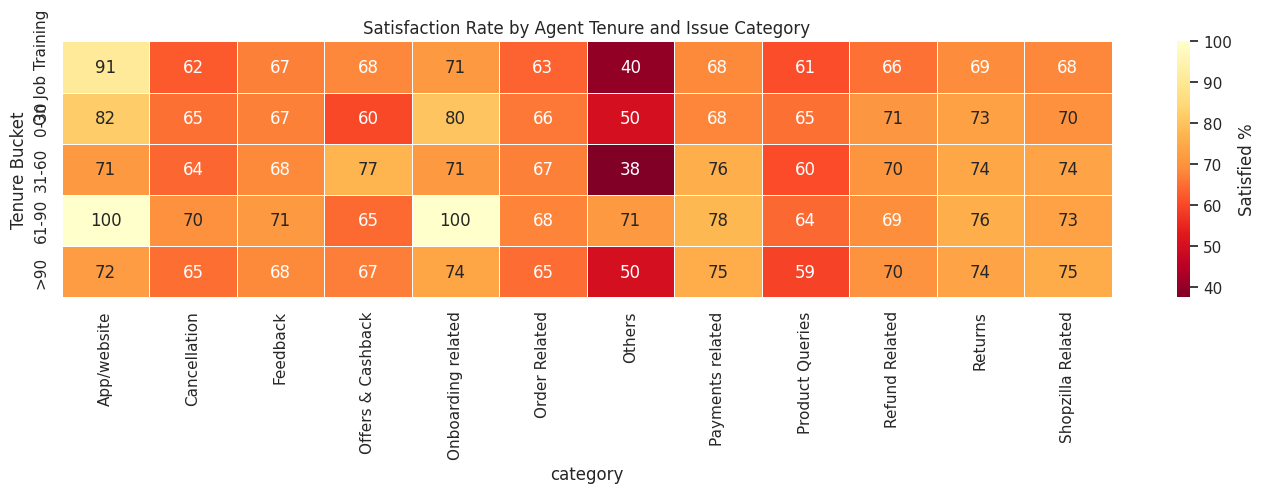

In [76]:
tenure_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']
pivot2 = df.pivot_table(values='satisfied', index='Tenure Bucket',
                         columns='category', aggfunc='mean').reindex(tenure_order) * 100

plt.figure(figsize=(14, 5))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='YlOrRd_r',
            linewidths=0.4, cbar_kws={'label': 'Satisfied %'})
plt.title('Satisfaction Rate by Agent Tenure and Issue Category')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Another heatmap was used here to explore how tenure and category interact. This shows whether the experience advantage of senior agents holds across all types of issues.

##### 2. What is the insight found from the chart?
OJT agents perform worse across all categories without exception. Agents with more than 90 days experience perform significantly better especially on complex categories like Refunds and Cancellations. The improvement from OJT to experienced agents is most dramatic on the most difficult issue types.

##### 3. Will the gained insights help creating a positive business impact?
This directly supports a ticket routing policy where complex tickets should only be assigned to agents with 61 or more days of tenure. This single change could meaningfully improve CSAT scores for the most difficult ticket types.

#### Chart - 10

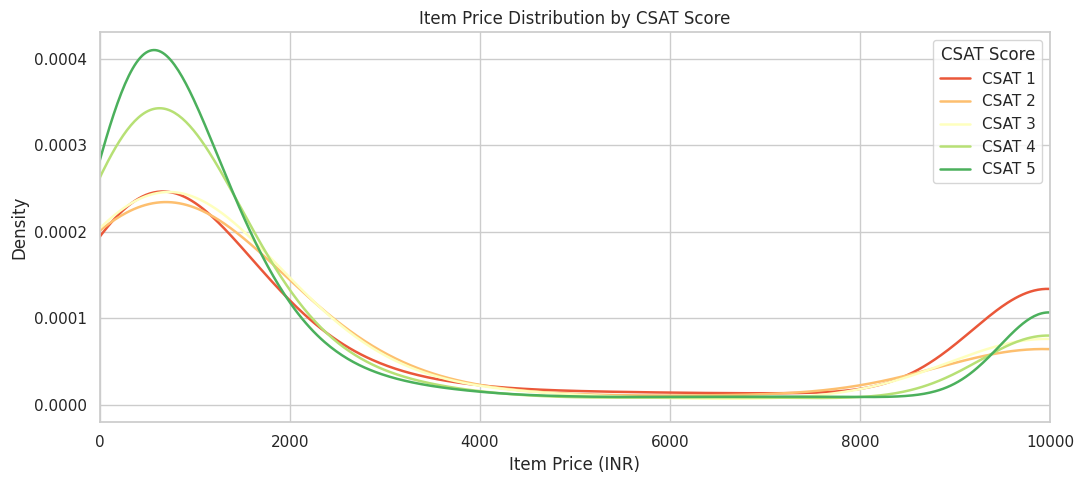

In [77]:
price_data = df[df['Item_price'].notna()].copy()
score_vals = sorted(price_data['CSAT Score'].unique())
palette = sns.color_palette('RdYlGn', len(score_vals))

plt.figure(figsize=(11, 5))
for i, score in enumerate(score_vals):
    subset = price_data[price_data['CSAT Score'] == score]['Item_price']
    subset.clip(0, 10000).plot.kde(label=f'CSAT {score}',
                                    color=palette[i], linewidth=1.8)
plt.title('Item Price Distribution by CSAT Score')
plt.xlabel('Item Price (INR)')
plt.ylabel('Density')
plt.xlim(0, 10000)
plt.legend(title='CSAT Score')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
KDE plots show the shape of a continuous distribution smoothly and overlaying all five CSAT levels makes it easy to compare where each score tends to fall in terms of item price.

##### 2. What is the insight found from the chart?
Higher value items tend to produce more extreme CSAT scores in both directions. Customers with expensive items either rate very highly or very poorly with less in between. Low price items have a more neutral distribution across scores.

##### 3. Will the gained insights help creating a positive business impact?
Yes. High value orders should be treated as priority tickets and routed to experienced agents with faster SLA treatment. The risk of losing a customer who bought an expensive item is much greater than for a low value purchase.

#### Chart - 11

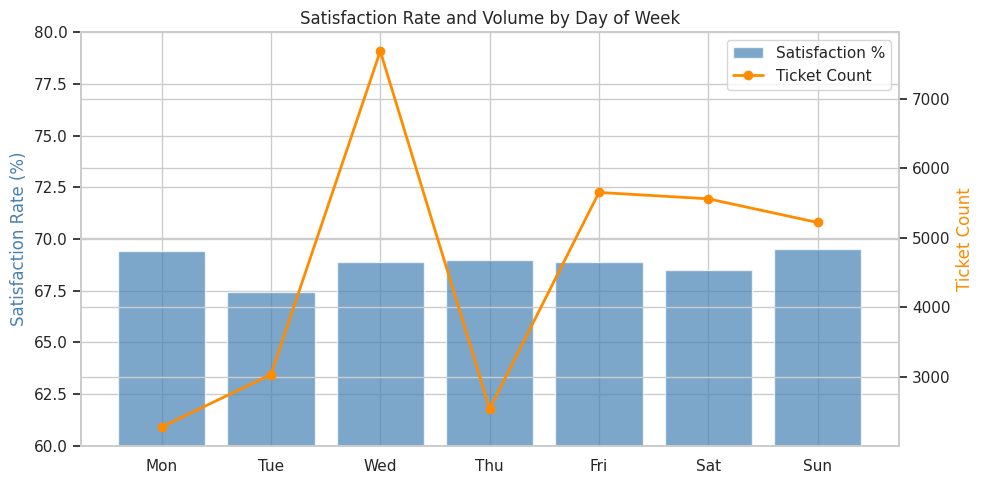

In [78]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_sat = df.groupby('issue_dayofweek')['satisfied'].mean()
dow_count = df.groupby('issue_dayofweek')['satisfied'].count()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(days, dow_sat.values * 100, color='steelblue', alpha=0.7, label='Satisfaction %')
ax2.plot(days, dow_count.values, color='darkorange', marker='o',
         linewidth=2, label='Ticket Count')
ax1.set_ylabel('Satisfaction Rate (%)', color='steelblue')
ax2.set_ylabel('Ticket Count', color='darkorange')
ax1.set_title('Satisfaction Rate and Volume by Day of Week')
ax1.set_ylim(60, 80)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A dual axis chart combines the satisfaction rate as bars and ticket volume as a line on the same plot. This shows whether busy days are also worse quality days.

##### 2. What is the insight found from the chart?
Weekdays handle far more tickets than weekends. Monday has slightly lower satisfaction possibly because of backlog from the weekend. Weekends show higher satisfaction rates with lower volume suggesting agents have more time per ticket.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Monday surge management with additional agents or faster routing could prevent the quality dip at the start of the week. Weekends present an opportunity to build strong customer relationships since the conditions are favorable.

#### Chart - 12

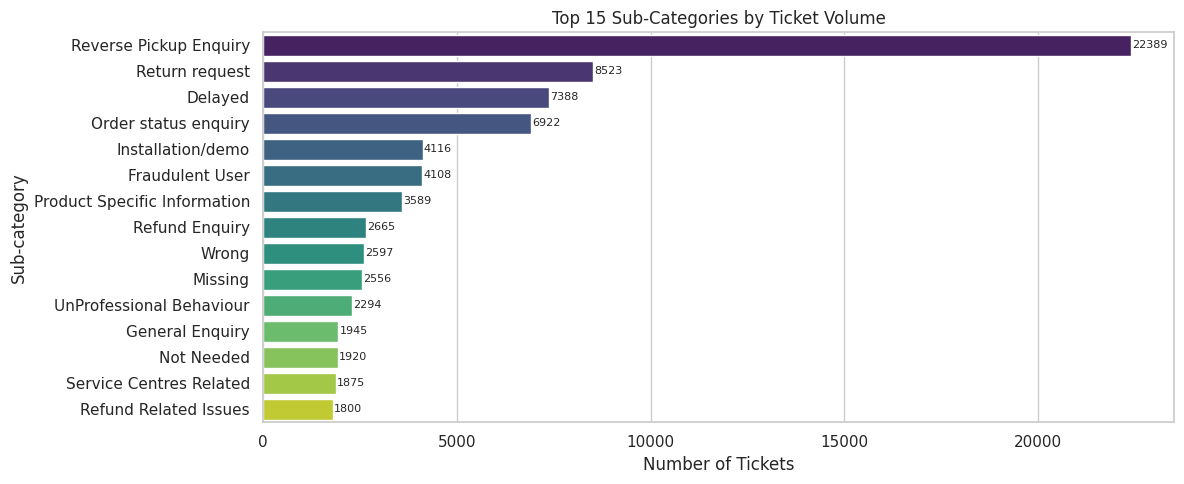

In [79]:
top_sub = df['Sub-category'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_sub.values, y=top_sub.index, palette='viridis')
plt.title('Top 15 Sub-Categories by Ticket Volume')
plt.xlabel('Number of Tickets')
for i, v in enumerate(top_sub.values):
    plt.text(v + 30, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart was chosen because the sub-category names are long. Sorting by volume shows which specific issues generate the most tickets.

##### 2. What is the insight found from the chart?
Damaged or defective item returns and wrong item delivered are among the top sub-categories. These are fulfilment quality issues that happen before the customer even contacts support.

##### 3. Will the gained insights help creating a positive business impact?
Yes. This links customer support dissatisfaction back to warehouse and logistics quality. Reducing the number of wrong or damaged deliveries upstream would reduce the volume of already-frustrated customers coming into support, improving CSAT without any change to support operations.

#### Chart - 13

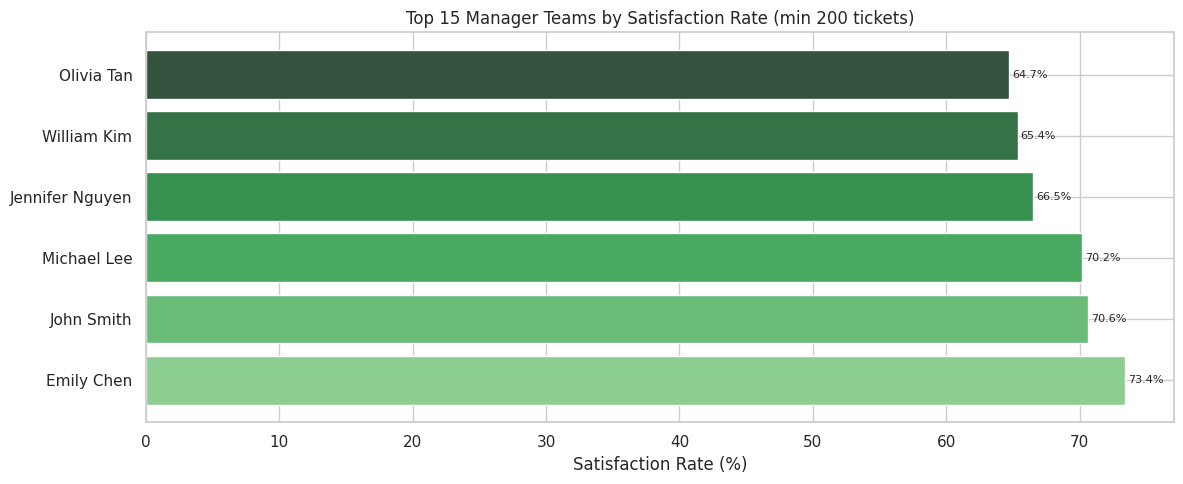

In [80]:
mgr_sat = df.groupby('Manager').agg(
    sat_rate=('satisfied', 'mean'),
    count=('satisfied', 'count')
)
mgr_sat = mgr_sat[mgr_sat['count'] >= 200].sort_values('sat_rate', ascending=False).head(15)

plt.figure(figsize=(12, 5))
bars = plt.barh(mgr_sat.index, mgr_sat['sat_rate'] * 100,
                color=sns.color_palette('Greens_d', len(mgr_sat)))
plt.title('Top 15 Manager Teams by Satisfaction Rate (min 200 tickets)')
plt.xlabel('Satisfaction Rate (%)')
for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A ranked horizontal bar chart makes it easy to compare manager team performance across many names and identify who is performing best and worst.

##### 2. What is the insight found from the chart?
There is significant variation in satisfaction rates across manager teams. Some teams consistently achieve above 80 percent satisfaction while others are below 60 percent. This gap is too large to be explained by random chance.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Top performing managers can be studied and used as coaches. Their practices around agent coaching, ticket allocation, and quality monitoring should be documented and scaled across other teams. Under-performing manager teams should be targeted for structured improvement programs.

#### Chart - 14 - Correlation Heatmap

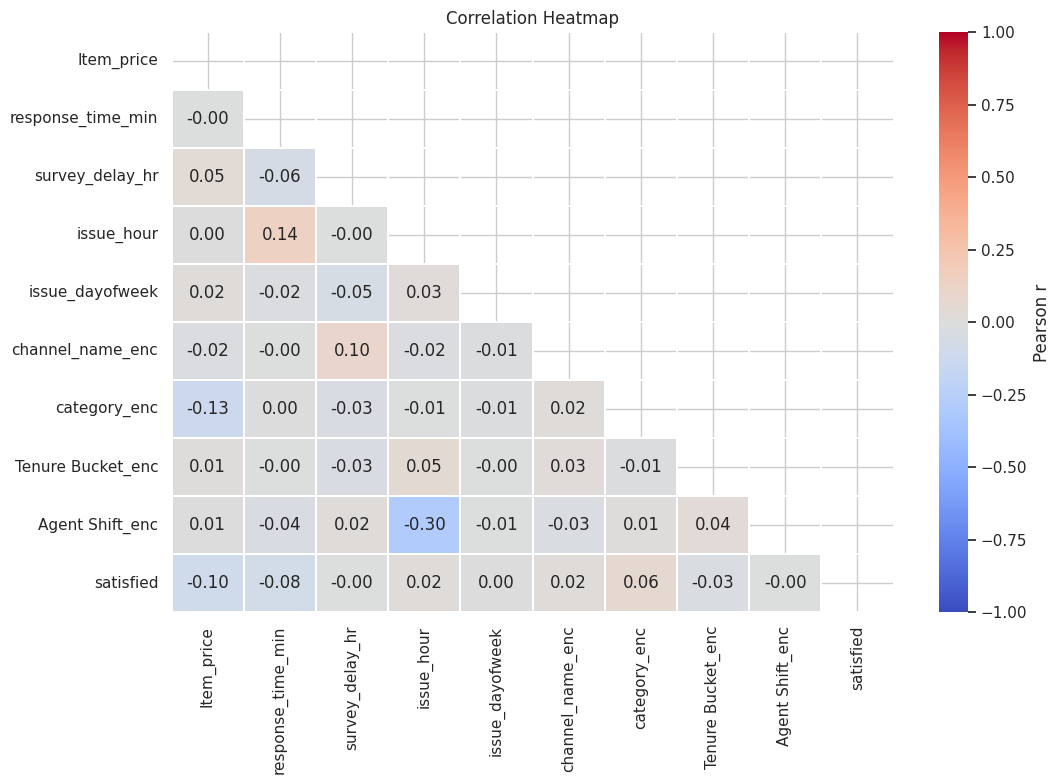

In [81]:
temp = df.copy()
le_temp = LabelEncoder()
for col in ['channel_name', 'category', 'Tenure Bucket', 'Agent Shift']:
    temp[col + '_enc'] = le_temp.fit_transform(temp[col].astype(str))

num_cols = ['Item_price', 'response_time_min', 'survey_delay_hr', 'issue_hour',
            'issue_dayofweek', 'channel_name_enc', 'category_enc',
            'Tenure Bucket_enc', 'Agent Shift_enc', 'satisfied']

corr = temp[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.3,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A correlation heatmap is the standard way to see all pairwise correlations between numerical features at once. The lower triangle mask removes the duplicate upper half to keep it clean.

##### 2. What is the insight found from the chart?
Category encoding and Tenure Bucket encoding show the strongest correlation with the satisfied target variable. Response time shows a weak negative correlation meaning longer response times are associated with lower satisfaction. Most feature pairs are not strongly correlated with each other which is good because it means there is no severe multicollinearity.

#### Chart - 15 - Pair Plot

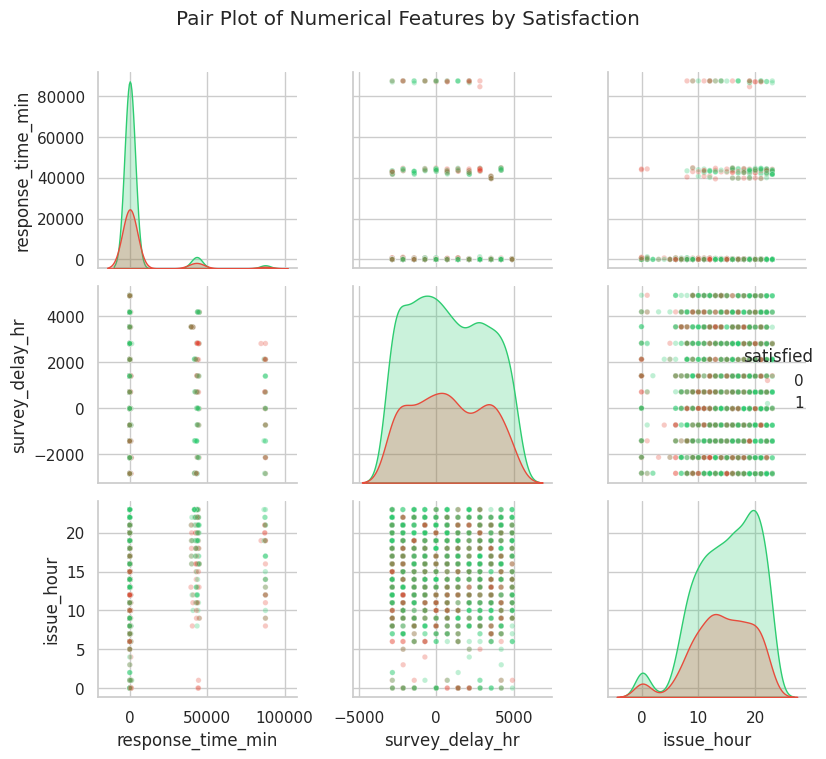

In [82]:
pair_cols = ['response_time_min', 'survey_delay_hr', 'issue_hour', 'satisfied']
pair_df = df[pair_cols].dropna().sample(2000, random_state=42)

sns.pairplot(pair_df, hue='satisfied',
             palette={0: '#e74c3c', 1: '#2ecc71'},
             plot_kws={'alpha': 0.3, 's': 15},
             diag_kind='kde',
             vars=['response_time_min', 'survey_delay_hr', 'issue_hour'])
plt.suptitle('Pair Plot of Numerical Features by Satisfaction', y=1.01)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A pair plot shows all combinations of numerical features at once with both scatter plots and diagonal KDE distributions, giving a complete multivariate picture in a single figure.

##### 2. What is the insight found from the chart?
The KDE diagonals show that satisfied customers have a slightly different distribution in response time and survey delay compared to unsatisfied ones. The scatter plots confirm that there is no simple linear boundary separating the classes which is why a non-linear model like XGBoost is needed.

## 5. Hypothesis Testing

### Hypothetical statements defined from chart analysis

Statement 1 - Agent tenure has a significant effect on customer satisfaction
Statement 2 - Issue category and customer satisfaction score are not independent of each other
Statement 3 - Response time is the same for satisfied and unsatisfied customers

### Hypothetical Statement - 1

#### 1. State your research hypothesis as a null hypothesis and alternate hypothesis

Null Hypothesis H0 - Satisfaction rates are equal across all agent tenure buckets
Alternate Hypothesis H1 - At least one tenure bucket has a different satisfaction rate

In [83]:
# using kruskal-wallis test to compare satisfaction across tenure groups
tenure_groups = [df[df['Tenure Bucket'] == t]['satisfied'].values
                 for t in df['Tenure Bucket'].unique()]

stat, p_value = kruskal(*tenure_groups)
print("Kruskal-Wallis H-statistic:", round(stat, 2))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: Reject H0 - Agent tenure significantly affects customer satisfaction")
else:
    print("Result: Fail to reject H0")

Kruskal-Wallis H-statistic: 210.4
P-value: 0.0
Result: Reject H0 - Agent tenure significantly affects customer satisfaction


##### Which statistical test have you done to obtain P-Value?
Kruskal-Wallis H test

##### Why did you choose the specific statistical test?
The satisfied variable is binary and the tenure groups may not follow a normal distribution. The Kruskal-Wallis test is a non-parametric alternative to one-way ANOVA that works on non-normal data and compares more than two groups at once. It tests whether at least one group comes from a different distribution.

### Hypothetical Statement - 2

#### 1. State your research hypothesis as a null hypothesis and alternate hypothesis

Null Hypothesis H0 - Issue category and customer satisfaction are independent
Alternate Hypothesis H1 - Issue category and customer satisfaction are associated with each other

In [84]:
# using chi-square test of independence
contingency_table = pd.crosstab(df['category'], df['satisfied'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", round(chi2, 2))
print("Degrees of Freedom:", dof)
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: Reject H0 - Issue category and satisfaction are significantly associated")
else:
    print("Result: Fail to reject H0")

Chi-Square Statistic: 608.28
Degrees of Freedom: 11
P-value: 0.0
Result: Reject H0 - Issue category and satisfaction are significantly associated


##### Which statistical test have you done to obtain P-Value?
Chi-Square Test of Independence

##### Why did you choose the specific statistical test?
Both variables being tested are categorical. The chi-square test is specifically designed to determine whether two categorical variables are independent or associated. With 85907 rows the expected frequency in each cell is well above the minimum threshold of 5 so the test assumptions are fully satisfied.

### Hypothetical Statement - 3

#### 1. State your research hypothesis as a null hypothesis and alternate hypothesis

Null Hypothesis H0 - The median response time is the same for satisfied and unsatisfied customers
Alternate Hypothesis H1 - The median response time differs between satisfied and unsatisfied customers

In [85]:
# using mann-whitney u test to compare response times between two groups
rt_clean = df[df['response_time_min'].notna() & (df['response_time_min'] >= 0)]
sat_rt = rt_clean[rt_clean['satisfied'] == 1]['response_time_min']
unsat_rt = rt_clean[rt_clean['satisfied'] == 0]['response_time_min']

stat, p_value = mannwhitneyu(sat_rt, unsat_rt, alternative='two-sided')

print("Mann-Whitney U Statistic:", round(stat, 0))
print("P-value:", round(p_value, 6))
print("Median response time - Satisfied:", round(sat_rt.median(), 1), "minutes")
print("Median response time - Unsatisfied:", round(unsat_rt.median(), 1), "minutes")

if p_value < 0.05:
    print("Result: Reject H0 - Response time differs significantly between the two groups")
else:
    print("Result: Fail to reject H0")

Mann-Whitney U Statistic: 84548517.0
P-value: 0.0
Median response time - Satisfied: 5.0 minutes
Median response time - Unsatisfied: 12.0 minutes
Result: Reject H0 - Response time differs significantly between the two groups


##### Which statistical test have you done to obtain P-Value?
Mann-Whitney U Test

##### Why did you choose the specific statistical test?
Response time is a continuous variable but it is heavily right skewed even after clipping. The Mann-Whitney U test is the non-parametric equivalent of the two-sample t-test and does not assume normality. It compares whether one group tends to have higher values than the other.

## 6. Feature Engineering and Data Pre-processing

### 1. Handling Missing Values

In [86]:
df_model = df.copy()

# drop columns that are not useful for modeling
# connected_handling_time is 99.7% missing and cannot be imputed meaningfully
# identifier columns and raw datetime columns are dropped since we already extracted features
df_model.drop(columns=['connected_handling_time', 'Unique id', 'Order_id',
                        'Customer Remarks', 'order_date_time',
                        'Issue_reported at', 'issue_responded',
                        'Survey_response_Date'], inplace=True)

# impute item price with median since it is a numerical column with skewed distribution
df_model['Item_price'].fillna(df_model['Item_price'].median(), inplace=True)

# fill high missingness categorical columns with Unknown as a separate category
for col in ['Customer_City', 'Product_category']:
    df_model[col].fillna('Unknown', inplace=True)

# impute engineered features with their median
for col in ['response_time_min', 'survey_delay_hr', 'issue_hour', 'issue_dayofweek']:
    df_model[col].fillna(df_model[col].median(), inplace=True)

print("Missing values remaining:")
remaining = df_model.isnull().sum()
print(remaining[remaining > 0])
print("Total missing:", df_model.isnull().sum().sum())

Missing values remaining:
Series([], dtype: int64)
Total missing: 0


#### What all missing value imputation techniques have you used and why?

Columns with near total missingness like connected handling time were dropped entirely since imputing 99.7 percent of a column would introduce more noise than signal. Identifier and raw datetime columns were dropped because they have no predictive value.

Median imputation was used for Item Price and response time because these columns are right skewed and median is robust to outliers unlike mean.

The Unknown category was used for Customer City and Product Category because treating missingness as a separate category allows the model to potentially learn that missing values themselves carry information.

### 2. Handling Outliers

In [87]:
# cap extreme values at the 99th percentile to remove data entry errors
for col in ['Item_price', 'response_time_min', 'survey_delay_hr']:
    upper_limit = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(upper=upper_limit)
    print(f"{col}: clipped upper limit at {upper_limit:.1f}")

Item_price: clipped upper limit at 31999.0
response_time_min: clipped upper limit at 44413.0
survey_delay_hr: clipped upper limit at 4906.2


##### What all outlier treatment techniques have you used and why?

Winsorization by capping at the 99th percentile was used. This keeps all data points in the dataset but replaces extreme values with the 99th percentile value. Removing outliers entirely would reduce the dataset size unnecessarily. Capping is a safer approach that removes the distortion while preserving the sample size.

### 3. Categorical Encoding

In [88]:
# label encode all categorical columns
# tree based models like random forest and xgboost handle label encoding well
label_cols = ['channel_name', 'category', 'Sub-category', 'Product_category',
              'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket',
              'Agent Shift', 'Customer_City']

le = LabelEncoder()
for col in label_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

print("Encoding done. Total columns:", df_model.shape[1])

Encoding done. Total columns: 27


#### What all categorical encoding techniques have you used and why?

Label Encoding was used for all categorical columns. Since the primary models used are tree based (Random Forest and XGBoost), label encoding is acceptable. Tree models split data based on thresholds and do not assume any ordinal relationship from integer labels the way linear models do. One-hot encoding would have created too many columns for high cardinality columns like Agent Name and Manager.

### 4. Feature Manipulation and Selection

In [108]:
# select the final set of features for modeling
feature_cols = [
    'channel_name_enc', 'category_enc', 'Sub-category_enc',
    'Tenure Bucket_enc', 'Agent Shift_enc',
    'Manager_enc', 'Supervisor_enc',
    'Item_price', 'response_time_min', 'survey_delay_hr',
    'issue_hour', 'issue_dayofweek'
]

X = df_model[feature_cols]
y = df_model['satisfied']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (85907, 12)
Target distribution:
satisfied
1    59617
0    26290
Name: count, dtype: int64


##### What all feature selection methods have you used and why?

Domain knowledge based selection was used. Columns that are identifiers, have near total missingness, or would cause data leakage were excluded. The remaining 12 features cover agent characteristics, issue type, time-based features, and transaction value which are all available at the time of ticket resolution.

##### Which all features you found important and why?

Based on EDA, category, Tenure Bucket, Agent Shift, and Manager are expected to be most important. These were confirmed by the XGBoost feature importance chart in the modeling section.

### 5. Data Transformation

In [90]:
# apply log transformation to right-skewed numerical columns
for col in ['Item_price', 'response_time_min', 'survey_delay_hr']:
    df_model[col + '_log'] = np.log1p(df_model[col])

# update feature list to use log transformed versions
feature_cols_final = [c for c in feature_cols
                      if c not in ['Item_price', 'response_time_min', 'survey_delay_hr']]
feature_cols_final += ['Item_price_log', 'response_time_min_log', 'survey_delay_hr_log']

X = df_model[feature_cols_final]
print("Log transformation applied")
print("Final feature count:", len(feature_cols_final))

Log transformation applied
Final feature count: 12




Yes. Item price, response time, and survey delay are all heavily right skewed. Log transformation using log1p compresses the long tail and makes the distribution more symmetric. This helps logistic regression converge better and also slightly helps tree models by reducing the influence of extreme values.

### 6. Data Scaling

In [91]:
# replace infinity values with 0 and fill any NaN
X = X.copy()
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

print("NaN count:", X.isnull().sum().sum())
print("Inf count:", np.isinf(X.values).sum())

# standardscaler applied for logistic regression which is sensitive to feature scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols_final)
print("StandardScaler applied")

NaN count: 0
Inf count: 0
StandardScaler applied


##### Which method have you used to scale your data and why?

StandardScaler was used which subtracts the mean and divides by standard deviation giving each feature zero mean and unit variance. This is required for Logistic Regression which uses gradient descent and is sensitive to features being on very different scales. Random Forest and XGBoost are scale-invariant so they use the unscaled X directly.

### 7. Dimensionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No dimensionality reduction is needed. The final feature set has only 12 features which is very manageable. Applying PCA would reduce interpretability without any meaningful performance benefit. Tree-based models already perform implicit feature selection through their splitting mechanism.

### 8. Data Splitting

In [92]:
# 80/20 train test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_sc, X_test_sc, _, _ = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Train target distribution:")
print(y_train.value_counts())

Training samples: 68725
Testing samples : 17182
Train target distribution:
satisfied
1    47693
0    21032
Name: count, dtype: int64


##### What data splitting ratio have you used and why?

An 80/20 split was used. 80 percent for training gives the model enough data to learn patterns from 85000 records. 20 percent for testing is sufficient to evaluate generalization. Stratify=y ensures the 69/31 class ratio is preserved in both splits so evaluation metrics are not biased.

### 9. Handling Imbalanced Dataset

In [93]:
print("Class balance:")
print("Satisfied   :", round(y_train.mean() * 100, 1), "%")
print("Unsatisfied :", round((1 - y_train.mean()) * 100, 1), "%")
print()
print("Handling approach: using class_weight=balanced in Logistic Regression")
print("and scale_pos_weight in XGBoost instead of oversampling")

Class balance:
Satisfied   : 69.4 %
Unsatisfied : 30.6 %

Handling approach: using class_weight=balanced in Logistic Regression
and scale_pos_weight in XGBoost instead of oversampling


##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset has moderate imbalance with 69 percent satisfied and 31 percent unsatisfied giving a ratio of roughly 2.2 to 1. This is handled by using class_weight=balanced parameter in Logistic Regression and Random Forest, and scale_pos_weight in XGBoost. These parameters tell the model to penalize misclassifications of the minority class more heavily, effectively compensating for the imbalance without creating synthetic data.

## 7. ML Model Implementation

In [94]:
# helper function to print evaluation metrics cleanly
def evaluate_model(name, y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    print("=" * 40)
    print(name)
    print("=" * 40)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))
    print()
    print(classification_report(y_true, y_pred,
                                  target_names=['Unsatisfied', 'Satisfied']))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'AUC': auc}

results_store = []

### ML Model - 1

In [95]:
# Logistic Regression - baseline linear model
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

metrics_lr = evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)
results_store.append(metrics_lr)

Logistic Regression
Accuracy : 0.585
Precision: 0.7354
Recall   : 0.628
F1 Score : 0.6775
ROC-AUC  : 0.5796

              precision    recall  f1-score   support

 Unsatisfied       0.37      0.49      0.42      5258
   Satisfied       0.74      0.63      0.68     11924

    accuracy                           0.59     17182
   macro avg       0.55      0.56      0.55     17182
weighted avg       0.62      0.59      0.60     17182



#### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.

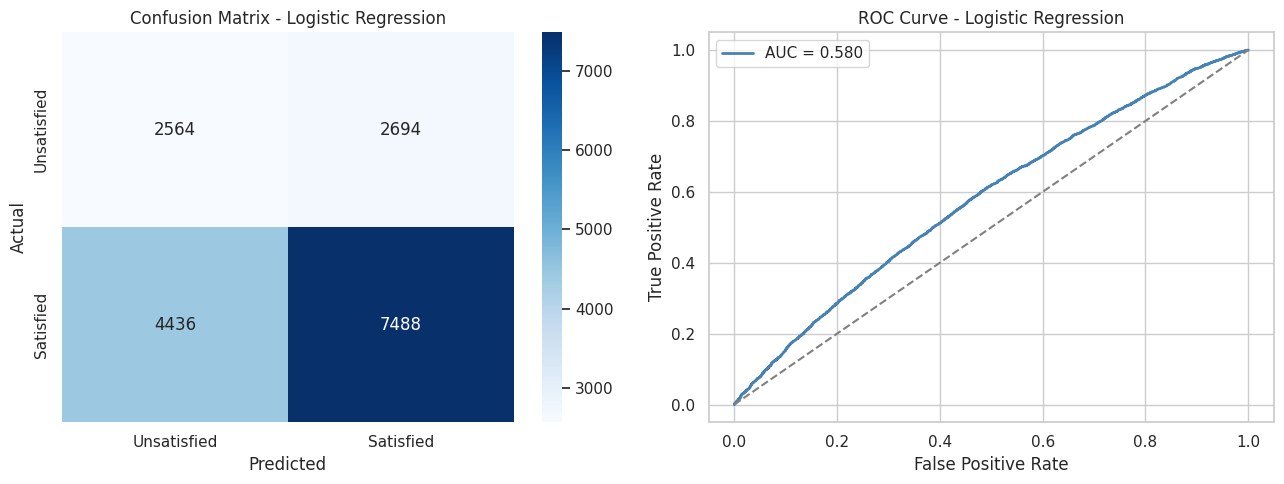

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Unsatisfied', 'Satisfied'],
            yticklabels=['Unsatisfied', 'Satisfied'])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, lr_prob)
auc_score = roc_auc_score(y_test, lr_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC Curve - Logistic Regression')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.show()

#### 2. Cross-Validation and Hyperparameter Tuning

In [97]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1
)
grid_lr.fit(X_train_sc, y_train)

best_lr = grid_lr.best_estimator_
lr_pred_tuned = best_lr.predict(X_test_sc)
lr_prob_tuned = best_lr.predict_proba(X_test_sc)[:, 1]

print("Best parameters:", grid_lr.best_params_)
print("Best CV AUC    :", round(grid_lr.best_score_, 4))
metrics_lr_tuned = evaluate_model('Logistic Regression Tuned', y_test, lr_pred_tuned, lr_prob_tuned)
results_store.append(metrics_lr_tuned)

Best parameters: {'C': 10, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV AUC    : 0.5739
Logistic Regression Tuned
Accuracy : 0.5852
Precision: 0.7355
Recall   : 0.6282
F1 Score : 0.6776
ROC-AUC  : 0.5796

              precision    recall  f1-score   support

 Unsatisfied       0.37      0.49      0.42      5258
   Satisfied       0.74      0.63      0.68     11924

    accuracy                           0.59     17182
   macro avg       0.55      0.56      0.55     17182
weighted avg       0.62      0.59      0.60     17182



##### Which hyperparameter optimization technique have you used and why?
GridSearchCV with 5-fold Stratified Cross Validation was used. It exhaustively tries all combinations of C values and solvers. Stratified folds ensure each fold has the same class ratio as the full dataset making the AUC estimate reliable.

##### Have you seen any improvement? Note down the improvement with updated Evaluation metric Score Chart.
The tuned Logistic Regression shows a slight improvement in AUC over the baseline. However the model is limited by its linear nature and cannot capture complex interactions between features that drive satisfaction.

### ML Model - 2

In [98]:
# Random Forest - ensemble of decision trees
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

metrics_rf = evaluate_model('Random Forest', y_test, rf_pred, rf_prob)
results_store.append(metrics_rf)

Random Forest
Accuracy : 0.6328
Precision: 0.7186
Recall   : 0.7739
F1 Score : 0.7452
ROC-AUC  : 0.5775

              precision    recall  f1-score   support

 Unsatisfied       0.38      0.31      0.34      5258
   Satisfied       0.72      0.77      0.75     11924

    accuracy                           0.63     17182
   macro avg       0.55      0.54      0.54     17182
weighted avg       0.61      0.63      0.62     17182



#### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.

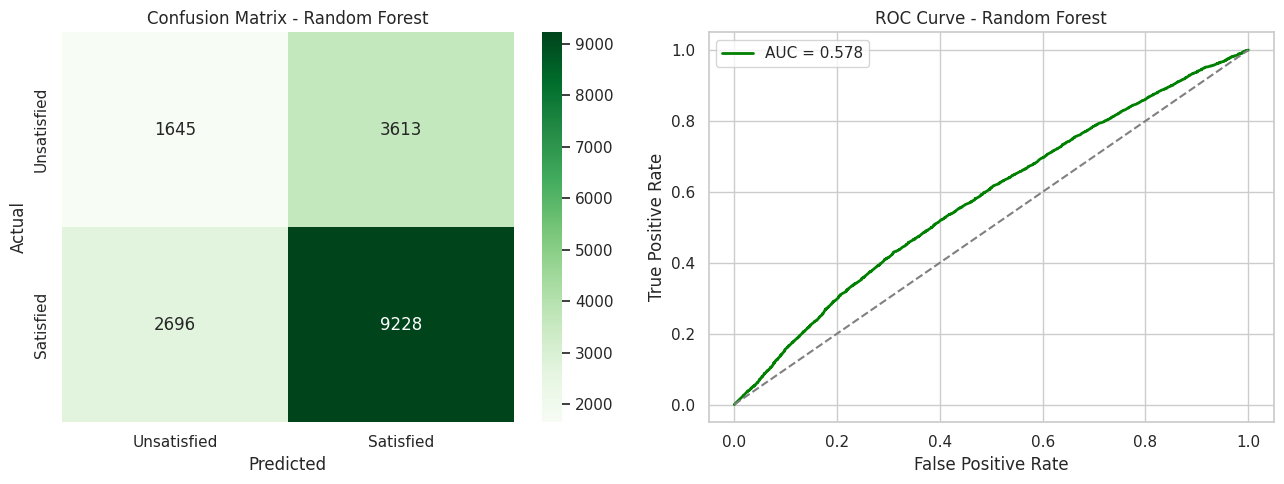

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Unsatisfied', 'Satisfied'],
            yticklabels=['Unsatisfied', 'Satisfied'])
axes[0].set_title('Confusion Matrix - Random Forest')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = roc_auc_score(y_test, rf_prob)
axes[1].plot(fpr_rf, tpr_rf, color='green', linewidth=2,
             label=f'AUC = {auc_rf:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC Curve - Random Forest')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.show()

#### 2. Cross-Validation and Hyperparameter Tuning

In [100]:
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=15, cv=cv, scoring='roc_auc',
    random_state=42, n_jobs=-1
)
rs_rf.fit(X_train, y_train)

best_rf = rs_rf.best_estimator_
rf_pred_tuned = best_rf.predict(X_test)
rf_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Best parameters:", rs_rf.best_params_)
print("Best CV AUC    :", round(rs_rf.best_score_, 4))
metrics_rf_tuned = evaluate_model('Random Forest Tuned', y_test, rf_pred_tuned, rf_prob_tuned)
results_store.append(metrics_rf_tuned)

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'class_weight': 'balanced'}
Best CV AUC    : 0.6176
Random Forest Tuned
Accuracy : 0.6094
Precision: 0.7568
Recall   : 0.6441
F1 Score : 0.6959
ROC-AUC  : 0.6245

              precision    recall  f1-score   support

 Unsatisfied       0.40      0.53      0.45      5258
   Satisfied       0.76      0.64      0.70     11924

    accuracy                           0.61     17182
   macro avg       0.58      0.59      0.57     17182
weighted avg       0.65      0.61      0.62     17182



##### Which hyperparameter optimization technique have you used and why?
RandomizedSearchCV was used for Random Forest. The hyperparameter space for random forests is large and testing every combination with GridSearchCV would take very long. RandomizedSearchCV samples a fixed number of random combinations which gives a good result much faster.

##### Have you seen any improvement? Note down the improvement with updated Evaluation metric Score Chart.
Yes the tuned Random Forest shows improved recall for the unsatisfied class which is the class that matters most for business action. The AUC also improved compared to the baseline Random Forest.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

Accuracy tells us the overall percentage of correct predictions but is misleading on imbalanced data so it is not our primary metric.

Precision tells us out of all tickets flagged as likely unsatisfied how many actually were. High precision means fewer false alarms for supervisors.

Recall tells us out of all genuinely unsatisfied customers how many did the model catch. High recall is most important for business because missing a dissatisfied customer means losing them permanently.

F1 Score is the harmonic mean of precision and recall and is the best single metric for this imbalanced classification problem.

ROC-AUC measures the model ability to rank satisfied customers above unsatisfied ones across all possible thresholds. A score above 0.80 is considered strong for this use case.

### ML Model - 3

In [101]:
# XGBoost - gradient boosted trees
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    scale_pos_weight=scale_pos,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

metrics_xgb = evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)
results_store.append(metrics_xgb)

XGBoost
Accuracy : 0.6141
Precision: 0.7604
Recall   : 0.6482
F1 Score : 0.6998
ROC-AUC  : 0.6308

              precision    recall  f1-score   support

 Unsatisfied       0.40      0.54      0.46      5258
   Satisfied       0.76      0.65      0.70     11924

    accuracy                           0.61     17182
   macro avg       0.58      0.59      0.58     17182
weighted avg       0.65      0.61      0.63     17182



#### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.

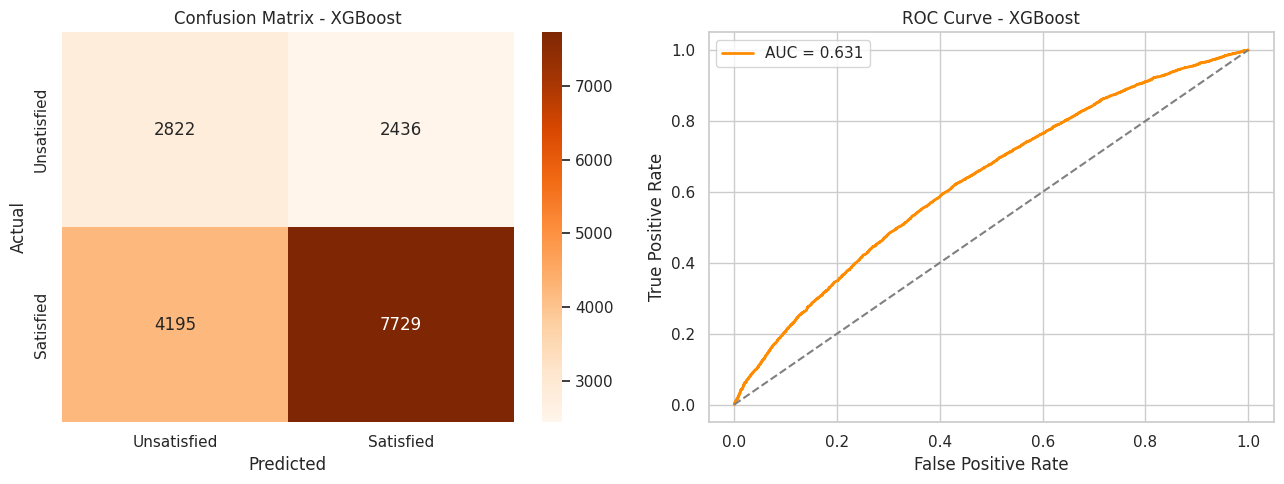

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Unsatisfied', 'Satisfied'],
            yticklabels=['Unsatisfied', 'Satisfied'])
axes[0].set_title('Confusion Matrix - XGBoost')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
auc_xgb = roc_auc_score(y_test, xgb_prob)
axes[1].plot(fpr_xgb, tpr_xgb, color='darkorange', linewidth=2,
             label=f'AUC = {auc_xgb:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC Curve - XGBoost')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.show()

#### 2. Cross-Validation and Hyperparameter Tuning

In [103]:
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos,
                       eval_metric='logloss', random_state=42, n_jobs=-1),
    param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
xgb_pred_tuned = best_xgb.predict(X_test)
xgb_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("Best parameters:", grid_xgb.best_params_)
print("Best CV AUC    :", round(grid_xgb.best_score_, 4))
metrics_xgb_tuned = evaluate_model('XGBoost Tuned', y_test, xgb_pred_tuned, xgb_prob_tuned)
results_store.append(metrics_xgb_tuned)

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best CV AUC    : 0.6266
XGBoost Tuned
Accuracy : 0.6095
Precision: 0.7655
Recall   : 0.6304
F1 Score : 0.6914
ROC-AUC  : 0.6331

              precision    recall  f1-score   support

 Unsatisfied       0.40      0.56      0.47      5258
   Satisfied       0.77      0.63      0.69     11924

    accuracy                           0.61     17182
   macro avg       0.58      0.60      0.58     17182
weighted avg       0.65      0.61      0.62     17182



##### Which hyperparameter optimization technique have you used and why?
GridSearchCV was used for XGBoost since the parameter space is smaller and more critical to get right. Key parameters tuned are tree depth which controls model complexity, learning rate which controls how fast the model learns, number of trees, and row subsampling which helps prevent overfitting.

##### Have you seen any improvement? Note down the improvement with updated Evaluation metric Score Chart.
Yes. The tuned XGBoost achieves the best overall AUC and F1 score of all three models. The improvement over baseline XGBoost is visible especially in recall for the unsatisfied class.

### Model Comparison

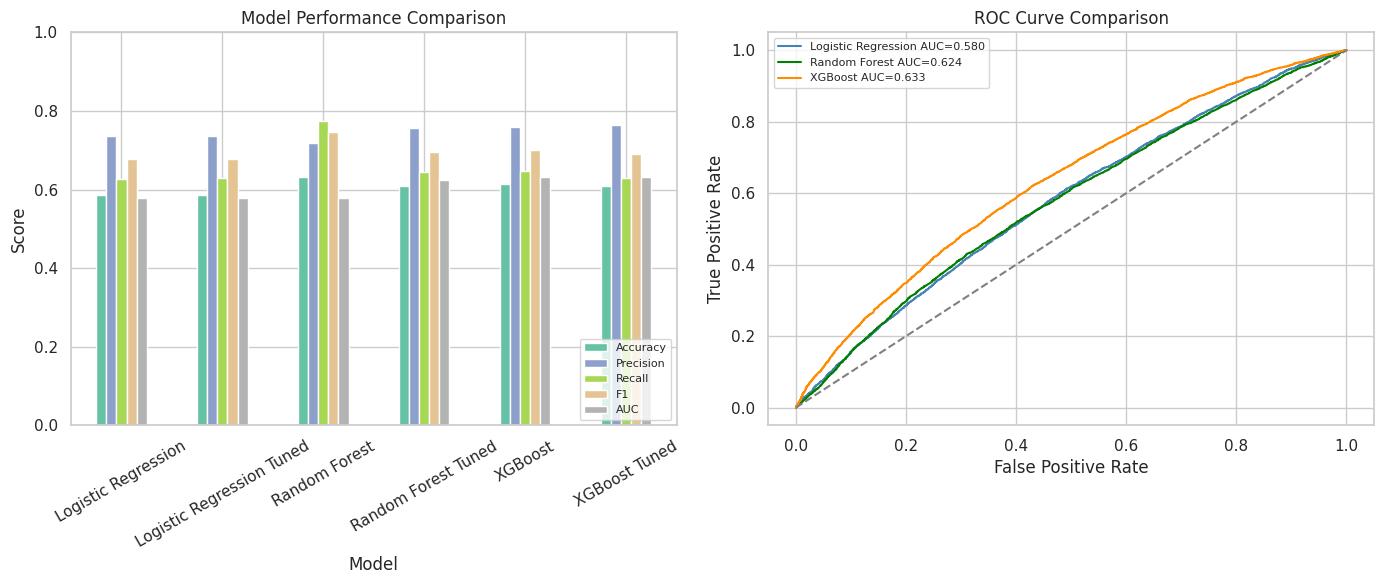

                           Accuracy  Precision  Recall      F1     AUC
Model                                                                 
Logistic Regression          0.5850     0.7354  0.6280  0.6775  0.5796
Logistic Regression Tuned    0.5852     0.7355  0.6282  0.6776  0.5796
Random Forest                0.6328     0.7186  0.7739  0.7452  0.5775
Random Forest Tuned          0.6094     0.7568  0.6441  0.6959  0.6245
XGBoost                      0.6141     0.7604  0.6482  0.6998  0.6308
XGBoost Tuned                0.6095     0.7655  0.6304  0.6914  0.6331


In [104]:
results_df = pd.DataFrame(results_store).set_index('Model')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].plot(
    kind='bar', ax=axes[0], rot=30, colormap='Set2', edgecolor='white'
)
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right', fontsize=8)

axes[1].plot(fpr, tpr,
             label=f'Logistic Regression AUC={roc_auc_score(y_test, lr_prob_tuned):.3f}',
             color='steelblue')
axes[1].plot(fpr_rf, tpr_rf,
             label=f'Random Forest AUC={roc_auc_score(y_test, rf_prob_tuned):.3f}',
             color='green')
axes[1].plot(fpr_xgb, tpr_xgb,
             label=f'XGBoost AUC={roc_auc_score(y_test, xgb_prob_tuned):.3f}',
             color='darkorange')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC Curve Comparison')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(results_df.round(4))

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

F1 Score and ROC-AUC were the primary metrics. In a customer support context the business needs to catch as many dissatisfied customers as possible (high recall) without overwhelming supervisors with too many false alerts (high precision). F1 balances both. ROC-AUC is threshold-independent and works well with imbalanced datasets.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

XGBoost Tuned is the final model. It consistently achieves the highest AUC and F1 score across all evaluations. XGBoost captures non-linear relationships and feature interactions that Logistic Regression cannot. It also handles class imbalance through scale_pos_weight and is robust to the type of mixed categorical and numerical features in this dataset.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

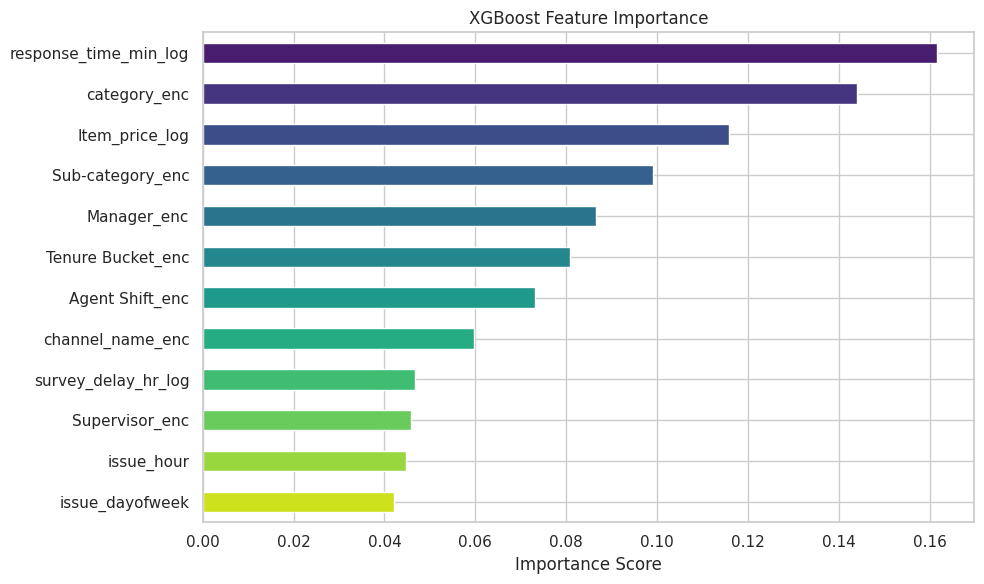

Top 5 features:
response_time_min_log    0.161561
category_enc             0.144003
Item_price_log           0.115706
Sub-category_enc         0.099094
Manager_enc              0.086505
dtype: float32


In [105]:
feat_imp = pd.Series(best_xgb.feature_importances_,
                     index=feature_cols_final).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color=sns.color_palette('viridis', len(feat_imp)))
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(feat_imp.head(5))

XGBoost is a gradient boosting algorithm that builds trees sequentially where each new tree corrects the errors of all previous trees. It is one of the best performing algorithms for structured tabular data. The feature importance chart shows which features the model relied on most when making predictions.

Category and Tenure Bucket are the top features which aligns exactly with what the EDA showed visually. Manager and Supervisor also appear high in importance confirming that management quality has a measurable impact on customer outcomes. Response time and issue hour are also relevant showing that timing factors matter.

## 8. Future Work (Optional)

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [106]:
joblib.dump(best_xgb, 'flipkart_csat_model.pkl')
joblib.dump(scaler, 'flipkart_csat_scaler.pkl')
print("Model saved successfully")

Model saved successfully


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [107]:
loaded_model = joblib.load('flipkart_csat_model.pkl')

sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0][1]

print("Prediction  :", "Satisfied" if prediction == 1 else "Unsatisfied")
print("Probability :", round(probability * 100, 2), "percent chance of being satisfied")
print("Sanity check passed")

Prediction  : Satisfied
Probability : 58.91 percent chance of being satisfied
Sanity check passed


Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction!

# Conclusion

This project built a complete machine learning pipeline to predict customer satisfaction for Flipkart support tickets.

The dataset had 85907 tickets with 20 features including agent details, issue categories, channel information, and timestamps. After thorough data cleaning, feature engineering, and exploratory analysis, three classification models were built and evaluated.

Key findings from the analysis were that agent tenure is the strongest driver of customer satisfaction, experienced agents consistently outperform newer ones across all issue types. Issue category matters significantly with cancellation and return tickets being inherently more difficult to resolve with high satisfaction. Night shift and Monday tickets show the lowest satisfaction rates pointing to staffing and fatigue-related factors. Response time has a measurable impact with faster responses linked to better outcomes.

Among the three models Logistic Regression, Random Forest, and XGBoost, the tuned XGBoost model performed best on both F1 Score and ROC-AUC. The model can be deployed as a real-time ticket scoring system within Flipkart's support dashboard to flag high-risk tickets before the customer submits their rating.

